# The Solver

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [3]:
# Constants
G = 1
c = 1
M = 0.5
# Schwarzchild Radius
rs = 2*G*M/(c**2)

In [5]:
def christoffel(a, b, c, r, theta): # 0 = t, 1 = r, 2 = theta, 3 = phi
    if(a == 1 and b == 0 and c == 0):
        return M*(r-2*M)/(r**3)
    if(a == 1 and b == 1 and c == 1):
        return -M/(r*(r-2*M))
    if(a == 1 and b == 2 and c == 2):
        return -(r-2*M)
    if(a == 1 and b == 3 and c == 3):
        return -(r-2*M)*(np.cos(theta)**2)
    if(a == 0 and b == 1 and c == 0):
        return M/(r*(r-2*M))
    if(a == 2 and b == 1 and c == 2):
        return 1/r
    if(a == 2 and b == 3 and c == 3):
        return -np.cos(theta) * np.sin(theta)
    if(a == 3 and b == 1 and c == 3):
        return 1/r
    if(a == 3 and b == 2 and c == 3):
        return np.sin(theta)/np.cos(theta)

In [6]:
def solve(l, r):
    t, r, theta, phi, v_t, v_r, v_th, v_p = r

    # DEs for positional coordinates
    f_t = v_t
    f_r = v_r
    f_th = v_th
    f_p = v_p

    # DEs for velocities
    f_v_t = -1*(2*christoffel(0,1,0,r,theta)*v_r*v_t)
    f_v_r = -1*(christoffel(1,0,0,r,theta)*v_t*v_t + christoffel(1,1,1,r,theta)*v_r*v_r + 
                christoffel(1,2,2,r,theta)*v_th*v_th + christoffel(1,3,3,r,theta)*v_p*v_p)
    f_v_th = -1*(2*christoffel(2,1,2,r,theta)*v_r*v_th + christoffel(2,3,3,r,theta)*v_p*v_p)
    f_v_p = -1*(2*christoffel(3,1,3,r,theta)*v_r*v_p + 2*christoffel(3,2,3,r,theta)*v_th*v_p)

    # REMEMBER! Christoffel Symbols are symmetric and both their symmetric terms have to be added.

    return f_t, f_r, f_th, f_p, f_v_t, f_v_r, f_v_th, f_v_p

In [58]:
def solver(v, r0, theta0, phi0, t0):
    cartesian_speeds = np.matrix([[v],[0],[0]])
    coefficients = np.matrix([[np.cos(theta0)*np.cos(phi0), -np.sin(theta0)*np.cos(phi0)*r0, -np.sin(phi0)*np.cos(theta0)*r0],
                              [np.sin(phi0)*np.cos(theta0), -np.sin(theta0)*np.sin(phi0)*r0, np.cos(phi0)*np.cos(theta0)*r0],
                              [np.sin(theta0), np.cos(theta0)*r0, 0]])

    velos = coefficients.I*cartesian_speeds
    
    
    v_r0, v_th0, v_p0 = velos[0,0], velos[1,0], velos[2,0]
    v_t0 = np.sqrt((v_r0**2/(1-rs/r0) + v_th0**2*r0**2 + v_p0**2*r0**2*np.cos(theta0)**2)/(1-rs/r0))
    
    sol = solve_ivp(solve, (1000,0), (t0, r0, theta0, phi0, v_t0, v_r0, v_th0, v_p0), 
                    t_eval=np.linspace(1000,0,100000), rtol=1e-8, atol=1e-10)

    return sol

# Raytracer

In [152]:
pixels = np.zeros((20,20,4))
solutions = []
pixel_width = 0.7*rs
center_x, center_y = 10, 10

r0 = 5*M
v = 0.5
t0 = 1000

for i in range(len(pixels)):
    for j in range(len(pixels[i])):
        for k in range(3):
            pixels[i,j,0] = np.sqrt(r0**2 + ((i-center_x)*pixel_width)**2 + ((j-center_y)*pixel_width)**2)
            pixels[i,j,1] = np.arctan((j-center_y)*pixel_width/r0)
            pixels[i,j,2] = np.arctan((i-center_x)*pixel_width/r0)

for i in range(len(pixels)):
    sol_list = []
    for j in range(len(pixels[i])):
        sol = solver(v, pixels[i,j,0], pixels[i,j,1], pixels[i,j,2], t0)
        sol_list.append(sol)
    solutions.append(sol_list)

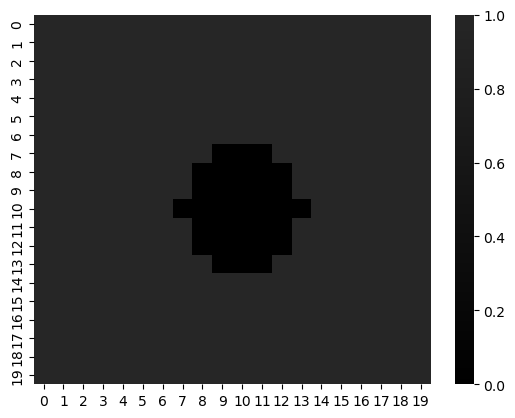

In [153]:
import seaborn as sns
import matplotlib.colors as mcolors

for i in range(len(pixels)):
    for j in range(len(pixels[i])):
        if(solutions[i][j].y[1,-1] <= rs+0.05):
            pixels[i,j,3] = 0
        else:
            pixels[i,j,3] = 1

cmap = mcolors.LinearSegmentedColormap.from_list(
    "black_grey", ["#000000", "#262626"]
)

sns.heatmap(
    pixels[:,:,3],
    cmap=cmap,
    vmin=0,
    vmax=1,
)
ax.tick_params(left=False, bottom=False)

# Gravitational Lensing

In [154]:
def convert_coordinates(r, theta, phi):
    x = r*np.cos(theta)*np.cos(phi)
    y = r*np.cos(theta)*np.sin(phi)
    z = r*np.sin(theta)

    return x,y,z

In [167]:
center_x, center_y, center_z = convert_coordinates(7*rs, 0, np.pi/2)
radius = rs

for i in range(len(pixels)):
    for j in range(len(pixels[i])):
        collision = False
        for k in range(len(solutions[i][j].y[0])):
            x, y, z = convert_coordinates(solutions[i][j].y[1,k], solutions[i][j].y[2,k], solutions[i][j].y[3,k])

            if((x-center_x)**2 + (y-center_y)**2 + (z-center_z)**2 <= radius**2):
                collision = True
                break
                
        if(collision == True):
            pixels[i,j,3] = 5

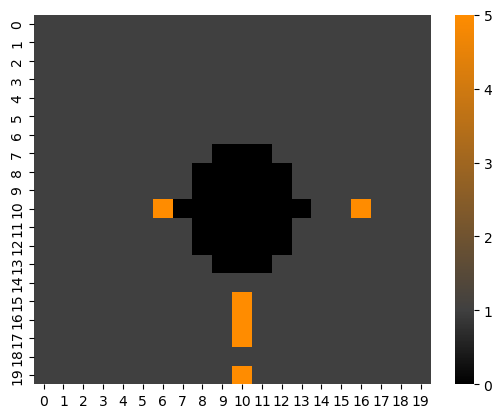

In [168]:
cmap = mcolors.LinearSegmentedColormap.from_list(
    "black_gray_orange",
    [(0.0, "#000000"),   # 0 -> black
     (0.2, "#404040"),   # 1 -> dark gray
     (1.0, "#ff8c00")]   # 5 -> orange
)

sns.heatmap(
    pixels[:,:,3],
    cmap=cmap,
    vmin=0,
    vmax=5,
)
ax.tick_params(left=False, bottom=False)

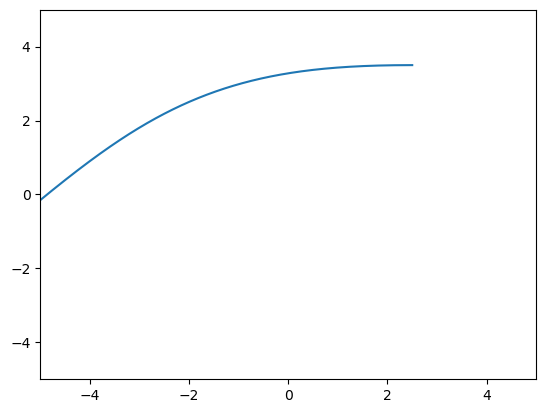

In [138]:
s = solver(v, pixels[15,10,0], pixels[15,10,1], pixels[15,10,2], t0)

x = s.y[1] * np.cos(s.y[3])
y = s.y[1] * np.sin(s.y[3])
plt.plot(x, y)
plt.xlim((-5,5))
plt.ylim((-5,5))
plt.show()


In [141]:
pixels[:, :, 3]

array([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 1., 1., 1., 1.,
        1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 1., 1., 1.,
        1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 1., 1., 1.,
        1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1.